# 🤖 Reconocimiento de dígitos con Redes Neuronales

## 1. Carga y exploración del dataset

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)
Pixel mínimo: 0
Pixel máximo: 255


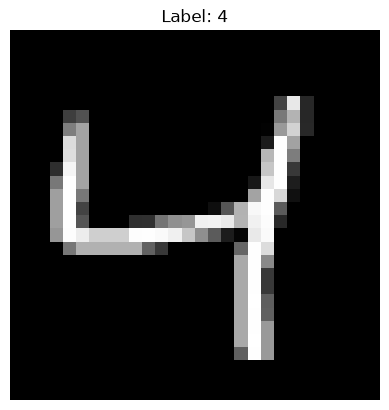

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#MNIST opr default ya esta dividido en train y test
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Pixel mínimo:", X_train.min())
print("Pixel máximo:", X_train.max())

plt.imshow(X_train[2], cmap="gray")
plt.title(f"Label: {y_train[2]}")
plt.axis("off")
plt.show()

---

## 2. Preprocesamiento


In [73]:
#Normalizamos los pixeles para trabajar en una escala más controlada
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Mínimo:", X_train.min())
print("Máximo:", X_train.max())

Mínimo: 0.0
Máximo: 1.0


___

## 3. Arquitectura
### Entrada
Procesamos la entrada con **Flatten** ya que sin este cada entrada es una matriz de 28 filas y 28 columnas. Las capas trabajan con listas de valores.

Usamos una capa oculta con 128 neuronas. Piénsalo como 128 pequeños "detectores de patrones" que buscan líneas, curvas y formas en los números. La capa de salida tiene 10 neuronas (una para cada dígito del 0 al 9), y usamos Softmax porque convierte esos valores en probabilidades (por ejemplo: "Hay un 95% de probabilidad de que sea un 3").

In [74]:
#Estructura de la RED
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    #Capa de activación
    tf.keras.layers.Dense(128, activation="relu"),
    #Capa calculo de probabilidad de la predicción
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_18 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Aprendizaje del modelo
- Aqui definimos el optimizador a ser usado. Para corregir los pesos.
- Como calcular el loss.
- Mostrar métricas de imagenes clasificadas correctamente.

In [75]:
model.compile(
    optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Entrenamiento base.
- Queremos que repita el dataset de entrenamiento un total de 10 veces.
- Por cada bacht analizará 32 imagenes.
- Apartamos 20% de entrenamiento para validación mientras se desarrolla el modelo y tomar decisiones.

In [76]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 876us/step - accuracy: 0.8134 - loss: 0.7378 - val_accuracy: 0.9000 - val_loss: 0.3865
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 875us/step - accuracy: 0.8969 - loss: 0.3661 - val_accuracy: 0.9137 - val_loss: 0.3127
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - accuracy: 0.9110 - loss: 0.3134 - val_accuracy: 0.9223 - val_loss: 0.2783
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step - accuracy: 0.9193 - loss: 0.2823 - val_accuracy: 0.9279 - val_loss: 0.2570
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 884us/step - accuracy: 0.9275 - loss: 0.2586 - val_accuracy: 0.9320 - val_loss: 0.2404
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 872us/step - accuracy: 0.9327 - loss: 0.2389 - val_accuracy: 0.9377 - val_loss: 0.2240
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 979us/step - accuracy: 0.9372 - loss: 0.2223 - val_accuracy: 0.9429 - val_loss: 0.2093
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9412 - l

___

# 4. Experimentos.

In [77]:
# Función para experimentos 
def build_model(activation="relu", optimizer="sgd"):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation=activation),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#### ReLU + SGD

In [78]:
#ReLU + SGD
model_relu_sgd = build_model("relu", "sgd")
print("ReLU + SGD")
history_relu_sgd = model_relu_sgd.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

ReLU + SGD
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - accuracy: 0.8250 - loss: 0.7012 - val_accuracy: 0.9016 - val_loss: 0.3738
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 794us/step - accuracy: 0.9026 - loss: 0.3570 - val_accuracy: 0.9162 - val_loss: 0.3078
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step - accuracy: 0.9153 - loss: 0.3054 - val_accuracy: 0.9235 - val_loss: 0.2735
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - accuracy: 0.9234 - loss: 0.2747 - val_accuracy: 0.9293 - val_loss: 0.2515
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 788us/step - accuracy: 0.9294 - loss: 0.2524 - val_accuracy: 0.9344 - val_loss: 0.2343
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 786us/step - accuracy: 0.9336 - loss: 0.2340 - val_accuracy: 0.9391 - val_loss: 0.2208
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - accuracy: 0.9377 - loss: 0.2184 - val_accuracy: 0.9435 - val_loss: 0.2069
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 790us/step - accurac

#### Sigmoid + SGD

In [79]:
#Sigmoid + SGD
model_sigmoid_sgd = build_model("sigmoid", "sgd")
print("Sigmoid + SGD")
history_sigmoid_sgd = model_sigmoid_sgd.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Sigmoid + SGD
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - accuracy: 0.6694 - loss: 1.5335 - val_accuracy: 0.8246 - val_loss: 0.9816
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 791us/step - accuracy: 0.8332 - loss: 0.8041 - val_accuracy: 0.8611 - val_loss: 0.6321
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - accuracy: 0.8630 - loss: 0.5921 - val_accuracy: 0.8823 - val_loss: 0.5036
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 808us/step - accuracy: 0.8771 - loss: 0.4990 - val_accuracy: 0.8909 - val_loss: 0.4391
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - accuracy: 0.8851 - loss: 0.4467 - val_accuracy: 0.8954 - val_loss: 0.4015
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - accuracy: 0.8901 - loss: 0.4132 - val_accuracy: 0.8995 - val_loss: 0.3751
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 803us/step - accuracy: 0.8941 - loss: 0.3899 - val_accuracy: 0.9022 - val_loss: 0.3569
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 852us/step - accu

#### ReLU + Adam

In [80]:
#ReLU + Adam
model_relu_adam = build_model("relu", "adam")
print("ReLU + Adam")
history_relu_adam = model_relu_adam.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

ReLU + Adam
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 993us/step - accuracy: 0.9183 - loss: 0.2907 - val_accuracy: 0.9565 - val_loss: 0.1498
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 924us/step - accuracy: 0.9629 - loss: 0.1270 - val_accuracy: 0.9645 - val_loss: 0.1207
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 964us/step - accuracy: 0.9739 - loss: 0.0864 - val_accuracy: 0.9718 - val_loss: 0.0965
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 947us/step - accuracy: 0.9807 - loss: 0.0650 - val_accuracy: 0.9739 - val_loss: 0.0876
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 984us/step - accuracy: 0.9851 - loss: 0.0491 - val_accuracy: 0.9743 - val_loss: 0.0878
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 937us/step - accuracy: 0.9880 - loss: 0.0387 - val_accuracy: 0.9750 - val_loss: 0.0832
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 946us/step - accuracy: 0.9909 - loss: 0.0304 - val_accuracy: 0.9746 - val_loss: 0.0892
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step - accura

#### Sigmoid + Adam

In [81]:
#Sigmoid + Adam
model_sigmoid_adam = build_model("sigmoid", "adam")
print("Sigmoid + Adam")
history_sigmoid_adam = model_sigmoid_adam.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Sigmoid + Adam
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8876 - loss: 0.4409 - val_accuracy: 0.9302 - val_loss: 0.2496
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 955us/step - accuracy: 0.9384 - loss: 0.2164 - val_accuracy: 0.9464 - val_loss: 0.1904
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 969us/step - accuracy: 0.9530 - loss: 0.1623 - val_accuracy: 0.9578 - val_loss: 0.1493
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 992us/step - accuracy: 0.9629 - loss: 0.1289 - val_accuracy: 0.9618 - val_loss: 0.1295
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 969us/step - accuracy: 0.9697 - loss: 0.1051 - val_accuracy: 0.9654 - val_loss: 0.1189
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 983us/step - accuracy: 0.9750 - loss: 0.0875 - val_accuracy: 0.9681 - val_loss: 0.1086
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 965us/step - accuracy: 0.9797 - loss: 0.0730 - val_accuracy: 0.9704 - val_loss: 0.1024
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 975us/step - accur

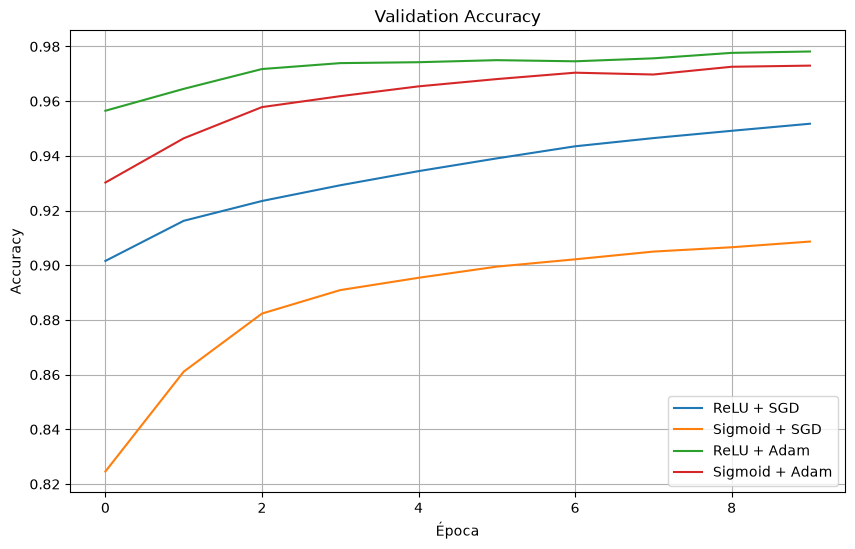

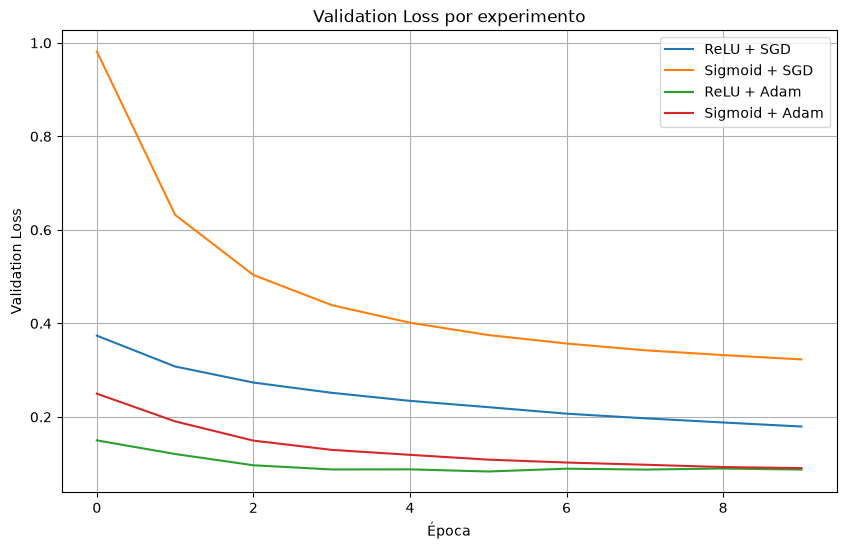

In [89]:
#Grafica Accuracy

plt.figure(figsize=(10, 6))

plt.plot(history_relu_sgd.history["val_accuracy"], label="ReLU + SGD")
plt.plot(history_sigmoid_sgd.history["val_accuracy"], label="Sigmoid + SGD")
plt.plot(history_relu_adam.history["val_accuracy"], label="ReLU + Adam")
plt.plot(history_sigmoid_adam.history["val_accuracy"], label="Sigmoid + Adam")

plt.title("Validation Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Grafica Loss
plt.figure(figsize=(10, 6))

plt.plot(history_relu_sgd.history["val_loss"],label="ReLU + SGD")
plt.plot(history_sigmoid_sgd.history["val_loss"],label="Sigmoid + SGD")
plt.plot(history_relu_adam.history["val_loss"],label="ReLU + Adam")
plt.plot(history_sigmoid_adam.history["val_loss"],label="Sigmoid + Adam")

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("Validation Loss por experimento")
plt.legend()
plt.grid(True)
plt.show()



___

# 5. Evaluación


### Para continuar, vamos a utilizar ReLU + Adam, porque en nuestros experimentos fue la configuración que obtuvo la mayor accuracy de validación al finalizar las 10 épocas: 97.59%.

In [83]:
model_final = build_model("relu", "adam")
history_final = model_final.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 972us/step - accuracy: 0.9186 - loss: 0.2897 - val_accuracy: 0.9516 - val_loss: 0.1638
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 925us/step - accuracy: 0.9620 - loss: 0.1292 - val_accuracy: 0.9651 - val_loss: 0.1176
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 971us/step - accuracy: 0.9743 - loss: 0.0879 - val_accuracy: 0.9683 - val_loss: 0.1055
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 923us/step - accuracy: 0.9802 - loss: 0.0652 - val_accuracy: 0.9744 - val_loss: 0.0866
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.9846 - loss: 0.0504 - val_accuracy: 0.9743 - val_loss: 0.0884
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 945us/step - accuracy: 0.9878 - loss: 0.0397 - val_accuracy: 0.9747 - val_loss: 0.0928
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 950us/step - accuracy: 0.9915 - loss: 0.0295 - val_accuracy: 0.9734 - val_loss: 0.1009
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step - accuracy: 0.9927 -

In [84]:
test_loss, test_accuracy = model_final.evaluate(
    X_test,
    y_test
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step - accuracy: 0.9762 - loss: 0.0848
Test loss: 0.08475582301616669
Test accuracy: 0.9761999845504761


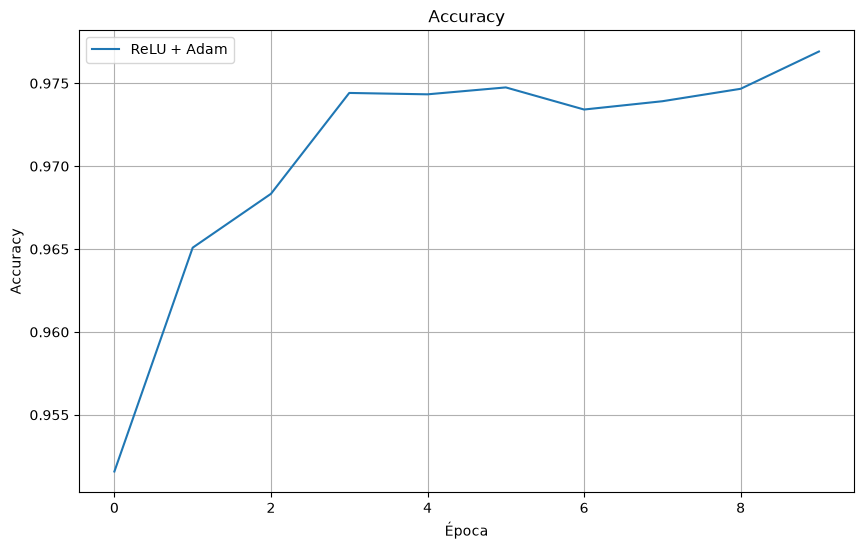

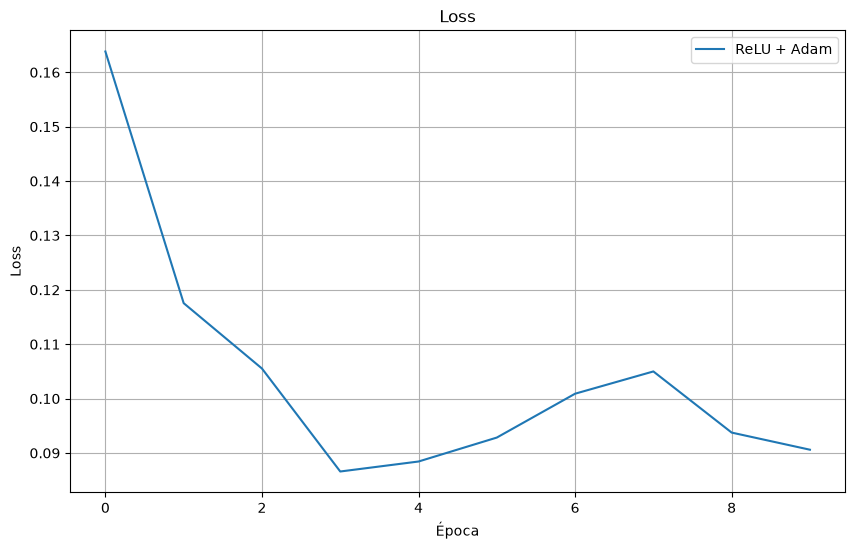

In [87]:
#Grafica Accuracy

plt.figure(figsize=(10, 6))

plt.plot(history_final.history["val_accuracy"], label="ReLU + Adam")

plt.title("Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Grafica Loss
plt.figure(figsize=(10, 6))

plt.plot(history_final.history["val_loss"],label="ReLU + Adam")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Aproximadamente 9.762 imágenes fueron clasificadas correctamente y unas 238 fueron clasificadas incorrectamente.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step


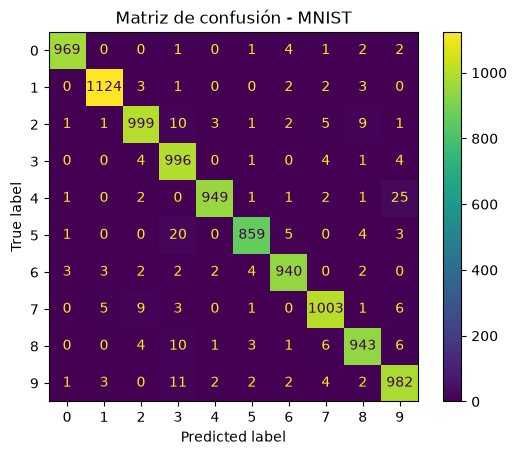

In [64]:
y_pred_prob = model_final.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)



cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot()
plt.title("Matriz de confusión - MNIST")
plt.show()

## Mi modelo tiene 97.62%, pero todavía confunde determinadas formas de dígitos, y aquí podemos observar un ejemplo concreto.

Cantidad de errores: 236
Índice de la imagen: 4807
Etiqueta real: 8
Predicción: 3


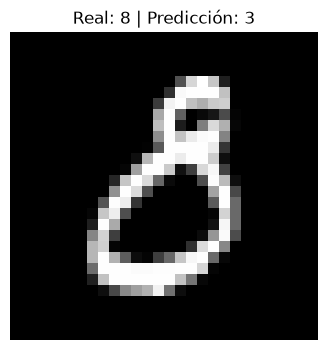

Probabilidades(que tan seguro estaba el modelo):
0: 0.0081
1: 0.0000
2: 0.0016
3: 0.9828
4: 0.0000
5: 0.0013
6: 0.0011
7: 0.0000
8: 0.0051
9: 0.0000


In [123]:
import random
incorrectos = np.where(y_test != y_pred)[0]

print("Cantidad de errores:", len(incorrectos))

i = random.choice(incorrectos)

print("Índice de la imagen:", i)
print("Etiqueta real:", y_test[i])
print("Predicción:", y_pred[i])

plt.figure(figsize=(4, 4))
plt.imshow(X_test[i], cmap="gray")
plt.title(
    f"Real: {y_test[i]} | Predicción: {y_pred[i]}"
)

plt.axis("off")
plt.show()


print("Probabilidades(que tan seguro estaba el modelo):")
for clase, probabilidad in enumerate(y_pred_prob[i]):
    print(f"{clase}: {probabilidad:.4f}")

# 6. Conclusiones

## Conclusiones de la evaluación

A partir de las métricas obtenidas, las curvas de **Loss/Accuracy** y la **matriz de confusión**, podemos evaluar el comportamiento de la red neuronal sobre el conjunto de prueba ReLU + Adam.

### Rendimiento general

El modelo logró clasificar correctamente la mayoría de las imágenes del conjunto de prueba, aunque presentó algunos errores de clasificación. Estos errores son esperables en un problema como MNIST, ya que algunos dígitos escritos a mano pueden presentar características visuales similares.

La matriz de confusión permitió identificar qué clases son más fáciles de reconocer y cuáles tienden a confundirse entre sí.

### Análisis de los errores

Se analizaron algunas de las imágenes clasificadas incorrectamente para observar qué estaba viendo el modelo. En algunos casos, la imagen podía presentar características similares a la clase predicha.

Por ejemplo, en uno de los errores analizados:

* **Etiqueta real:** `8`
* **Predicción:** `3`
* **Probabilidad para 3:** `47.85%`
* **Probabilidad para 8:** `37.14%`

Al observar la imagen, se comprobó que efectivamente correspondía al número `8`. Sin embargo, el modelo también asignó una probabilidad considerable a la clase `3`, lo que indica que existía cierta ambigüedad en la representación del dígito.

Esto permite comprobar que una predicción incorrecta no necesariamente significa que el modelo haya realizado una clasificación completamente aleatoria. Las probabilidades permiten conocer qué tan seguro estaba el modelo y qué otras clases consideraba posibles.

### Conclusión

La evaluación permitió comprobar que la red neuronal aprendió correctamente patrones visuales presentes en los dígitos escritos a mano y que puede generalizar esos patrones a imágenes que no utilizó durante el entrenamiento.

Al mismo tiempo, el análisis de los errores muestra que todavía existen casos difíciles de clasificar, principalmente cuando la forma de un dígito comparte características con otra clase.

Por lo tanto, además de observar la **accuracy**, resulta importante analizar la **loss**, la **matriz de confusión** y ejemplos concretos de errores. Estas herramientas permiten obtener una visión más completa del comportamiento del modelo y entender no solamente **cuánto acierta**, sino también **dónde y cómo se equivoca**.
